Using device: cuda
  GPU: Tesla T4
Pneumonia Detection — ResNet18 (ZIP version)
Extracting /content/drive/MyDrive/archive (1).zip ...
Extracted to: /content/pneumonia_dataset

Dataset located at: /content/pneumonia_dataset/chest_xray
  Train : /content/pneumonia_dataset/chest_xray/train
  Val   : /content/pneumonia_dataset/chest_xray/val
  Test  : /content/pneumonia_dataset/chest_xray/test

Dataset re-split (stratified 80/20):
  Combined  :  5232 images
  New train :  4185 images
  New val   :  1047 images
    Train NORMAL: 1079
    Train PNEUMONIA: 3106
    Val NORMAL: 270
    Val PNEUMONIA: 777

Test set : 624 images | Classes: ['NORMAL', 'PNEUMONIA']

Model: ResNet18  |  Total: 11,308,097  |  Trainable: 131,585
  pos_weight: 0.35  (NORMAL: 1079, PNEUMONIA: 3106)
Epoch [01/20] | 80s | lr=9.94e-05 | Train Loss=0.2234 Acc=0.8358 | Val Loss=0.1345 Acc=0.9121
  ✓ New best val accuracy: 0.9121
Epoch [02/20] | 78s | lr=9.76e-05 | Train Loss=0.1298 Acc=0.9082 | Val Loss=0.1033 Acc=0.9351
  

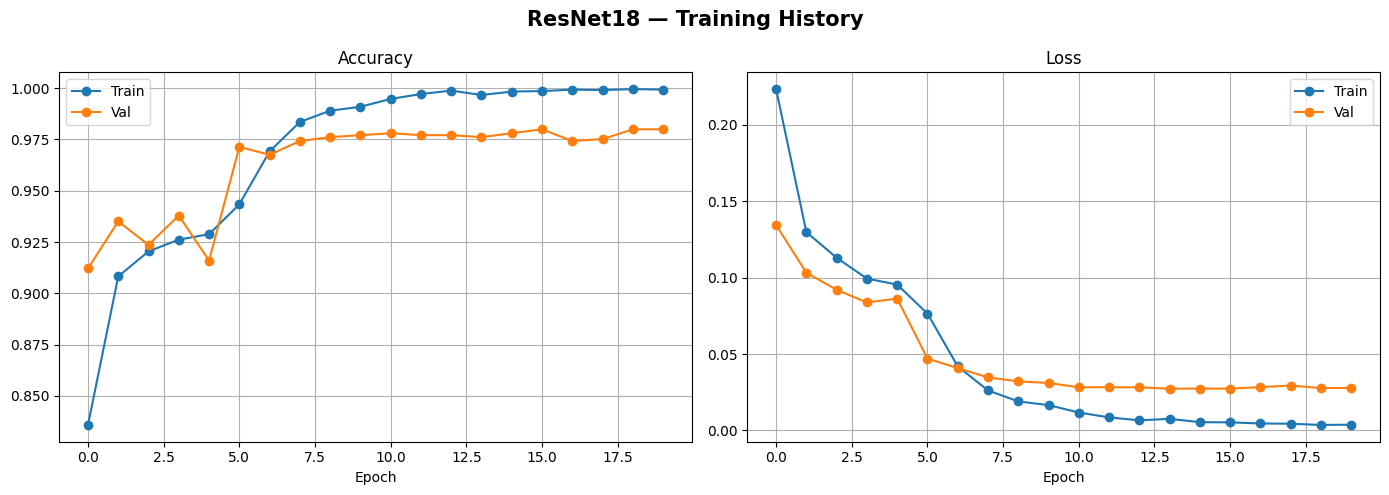


TEST SET EVALUATION — ResNet18
Test Loss     : 0.6179
Test Accuracy : 0.8381


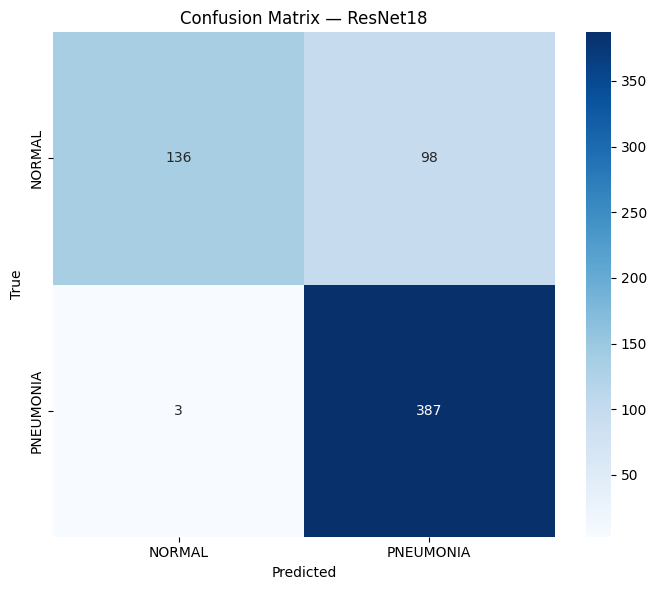


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.98      0.58      0.73       234
   PNEUMONIA       0.80      0.99      0.88       390

    accuracy                           0.84       624
   macro avg       0.89      0.79      0.81       624
weighted avg       0.87      0.84      0.83       624

Model saved: best_pneumonia_resnet18.pth


In [ ]:
import os, random, time, copy, zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, ConcatDataset
from torchvision import datasets, transforms, models
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, classification_report


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True


class Config:

    ZIP_PATH        = "/content/drive/MyDrive/archive (1).zip"
    EXTRACT_DIR     = "/content/pneumonia_dataset"


    IMG_SIZE        = 224
    MEAN            = [0.485, 0.456, 0.406]
    STD             = [0.229, 0.224, 0.225]

    BATCH_SIZE      = 32
    EPOCHS          = 20
    LR              = 1e-4
    LR_FINETUNE     = 1e-5
    WEIGHT_DECAY    = 2e-4
    DROPOUT         = 0.5
    VAL_SPLIT       = 0.20
    PATIENCE        = 5

    IN_FEATURES     = 512
    NUM_CLASSES     = 1
    FREEZE_EPOCHS   = 5


cfg = Config()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")



def extract_zip(zip_path, extract_dir):
    """
    Extract zip and auto-locate chest_xray/train/val/test folders.
    Handles nested folder structures from Kaggle downloads.
    """
    if not os.path.exists(zip_path):
        raise FileNotFoundError(
            f"\n[ERROR] Zip file not found at: {zip_path}\n"
            f"  → Upload your zip to Colab and update ZIP_PATH in Config."
        )

    print(f"Extracting {zip_path} ...")
    os.makedirs(extract_dir, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(extract_dir)

    print(f"Extracted to: {extract_dir}")


    chest_xray_dir = None
    for root, dirs, _ in os.walk(extract_dir):
        if "chest_xray" in dirs:
            chest_xray_dir = os.path.join(root, "chest_xray")
            break
        if os.path.basename(root) == "chest_xray":
            chest_xray_dir = root
            break

    if chest_xray_dir is None:
        for root, dirs, _ in os.walk(extract_dir):
            if "train" in dirs and "test" in dirs:
                chest_xray_dir = root
                break

    if chest_xray_dir is None:
        raise RuntimeError(
            f"\n[ERROR] Could not find chest_xray/train/val/test inside the zip.\n"
            f"  → Check your zip structure. Extracted contents: {extract_dir}"
        )

    train_dir = os.path.join(chest_xray_dir, "train")
    val_dir   = os.path.join(chest_xray_dir, "val")
    test_dir  = os.path.join(chest_xray_dir, "test")

    for split, path in [("train", train_dir), ("val", val_dir), ("test", test_dir)]:
        if not os.path.exists(path):
            raise RuntimeError(f"[ERROR] '{split}' folder not found at: {path}")

    print(f"\nDataset located at: {chest_xray_dir}")
    print(f"  Train : {train_dir}")
    print(f"  Val   : {val_dir}")
    print(f"  Test  : {test_dir}")
    return train_dir, val_dir, test_dir


train_transforms = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(cfg.MEAN, cfg.STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(cfg.MEAN, cfg.STD),
])

def merge_and_split(train_dir, val_dir, val_ratio=0.20):
    full_train = datasets.ImageFolder(train_dir, transform=val_test_transforms)
    full_val   = datasets.ImageFolder(val_dir,   transform=val_test_transforms)

    all_targets = full_train.targets + full_val.targets
    all_indices = list(range(len(full_train) + len(full_val)))

    sss = StratifiedShuffleSplit(n_splits=1, test_size=val_ratio,
                                 random_state=SEED)
    train_idx, val_idx = next(sss.split(all_indices, all_targets))

    combined  = ConcatDataset([full_train, full_val])
    new_train = Subset(combined, train_idx)
    new_val   = Subset(combined, val_idx)

    print(f"\nDataset re-split (stratified 80/20):")
    print(f"  Combined  : {len(combined):>5} images")
    print(f"  New train : {len(new_train):>5} images")
    print(f"  New val   : {len(new_val):>5} images")

    t_arr   = np.array(all_targets)
    classes = full_train.classes
    for split_name, idx in [("Train", train_idx), ("Val", val_idx)]:
        labels = t_arr[idx]
        for c_idx, c_name in enumerate(classes):
            print(f"    {split_name} {c_name}: {(labels == c_idx).sum()}")

    return new_train, new_val, full_train.classes

def apply_transforms_to_subset(subset, transform):
    for ds in subset.dataset.datasets:
        ds.transform = transform


def get_dataloaders(train_dir, val_dir, test_dir):
    train_subset, val_subset, class_names = merge_and_split(
        train_dir, val_dir, cfg.VAL_SPLIT
    )
    apply_transforms_to_subset(train_subset, train_transforms)
    apply_transforms_to_subset(val_subset,   val_test_transforms)

    test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

    train_loader = DataLoader(train_subset, batch_size=cfg.BATCH_SIZE,
                              shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_subset,   batch_size=cfg.BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_dataset, batch_size=cfg.BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)

    print(f"\nTest set : {len(test_dataset)} images | Classes: {class_names}")
    return train_loader, val_loader, test_loader, class_names


def build_model():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    for param in model.parameters():
        param.requires_grad = False


    model.fc = nn.Sequential(
        nn.Linear(cfg.IN_FEATURES, 256),
        nn.ReLU(),
        nn.Dropout(cfg.DROPOUT),
        nn.Linear(256, cfg.NUM_CLASSES),
    )

    model = model.to(DEVICE)
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel: ResNet18  |  Total: {total:,}  |  Trainable: {trainable:,}")
    return model


def unfreeze_all_layers(model):
  for name, param in model.named_parameters():
    if any(name.startswith(k) for k in ["layer4", "fc"]):
        param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Fine-tuning: ALL {trainable:,} params now trainable")



def get_pos_weight(train_loader):
    all_labels = []
    for _, labels in train_loader:
        all_labels.extend(labels.tolist())
    arr = np.array(all_labels)
    neg, pos = (arr == 0).sum(), (arr == 1).sum()
    w = neg / max(pos, 1)
    print(f"  pos_weight: {w:.2f}  (NORMAL: {neg}, PNEUMONIA: {pos})")
    return torch.tensor([w], dtype=torch.float32).to(DEVICE)


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.float().unsqueeze(1).to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds   = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.float().unsqueeze(1).to(DEVICE)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        preds   = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, correct / total

def train(model, train_loader, val_loader):
    pos_weight = get_pos_weight(train_loader)
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cfg.EPOCHS, eta_min=1e-7
    )

    history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  []}
    best_val_acc, best_weights = 0.0, copy.deepcopy(model.state_dict())
    patience_counter = 0

    for epoch in range(1, cfg.EPOCHS + 1):
        if epoch == cfg.FREEZE_EPOCHS + 1:
            print(f"\n── Epoch {epoch}: Switching to fine-tuning (all layers) ──")
            unfreeze_all_layers(model)
            optimizer = optim.AdamW(
                model.parameters(),
                lr=cfg.LR_FINETUNE, weight_decay=cfg.WEIGHT_DECAY
            )
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=cfg.EPOCHS - cfg.FREEZE_EPOCHS, eta_min=1e-7
            )

        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        print(f"Epoch [{epoch:02d}/{cfg.EPOCHS}] | {time.time()-t0:.0f}s "
              f"| lr={scheduler.get_last_lr()[0]:.2e} "
              f"| Train Loss={tr_loss:.4f} Acc={tr_acc:.4f} "
              f"| Val Loss={vl_loss:.4f} Acc={vl_acc:.4f}")

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
            print(f"  ✓ New best val accuracy: {best_val_acc:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= cfg.PATIENCE:
                print(f"\nEarly stopping at epoch {epoch}.")
                break

    model.load_state_dict(best_weights)
    print(f"\nBest Val Accuracy: {best_val_acc:.4f}")
    return model, history



def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("ResNet18 — Training History", fontsize=15, fontweight="bold")
    axes[0].plot(history["train_acc"],  label="Train", marker="o")
    axes[0].plot(history["val_acc"],    label="Val",   marker="o")
    axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch")
    axes[0].legend(); axes[0].grid(True)
    axes[1].plot(history["train_loss"], label="Train", marker="o")
    axes[1].plot(history["val_loss"],   label="Val",   marker="o")
    axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch")
    axes[1].legend(); axes[1].grid(True)
    plt.tight_layout()
    plt.savefig("training_history_resnet18.png", dpi=150)
    plt.show()


@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        outputs = model(images.to(DEVICE))
        probs   = torch.sigmoid(outputs).squeeze(1).cpu().numpy()
        all_preds.extend((probs > 0.5).astype(int).tolist())
        all_labels.extend(labels.numpy().tolist())
    return np.array(all_labels), np.array(all_preds)


def full_evaluation(model, test_loader, class_names):
    print("\n" + "="*60)
    print("TEST SET EVALUATION — ResNet18")
    print("="*60)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([1.0]).to(DEVICE))
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    print(f"Test Loss     : {test_loss:.4f}")
    print(f"Test Accuracy : {test_acc:.4f}")

    y_true, y_pred = get_predictions(model, test_loader)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.title("Confusion Matrix — ResNet18")
    plt.tight_layout()
    plt.savefig("confusion_matrix_resnet18.png", dpi=150)
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))


def main():
    print("="*60)
    print("Pneumonia Detection — ResNet18 (ZIP version)")
    print("="*60)

    train_dir, val_dir, test_dir = extract_zip(cfg.ZIP_PATH, cfg.EXTRACT_DIR)

    train_loader, val_loader, test_loader, class_names = get_dataloaders(
        train_dir, val_dir, test_dir
    )


    model = build_model()

    model, history = train(model, train_loader, val_loader)

    plot_history(history)
    full_evaluation(model, test_loader, class_names)


    torch.save(model.state_dict(), "best_pneumonia_resnet18.pth")
    print("Model saved: best_pneumonia_resnet18.pth")


if __name__ == "__main__":
    main()